In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.impute import MissingIndicator
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from IPython.display import Image
%matplotlib inline
sns.set(style="ticks")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
drive_file_path = "/content/drive/MyDrive/Consumer_Shopping_Trends_2026 (6).csv"
data = pd.read_csv("/content/drive/MyDrive/Consumer_Shopping_Trends_2026 (6).csv")
data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference
0,56,221111,6.5,12.0,0.7,1.0,NaN,16.0,16.0,28551,...,7.0,7.0,1.0,3.0,6.0,5,2,Other,Tier 3,Store
1,69,96029,8.2,13.0,2.7,NaN,9.0,14.0,1.0,124056,...,3.0,4.0,9.0,6.0,8.0,1,7,Male,Tier 3,Hybrid
2,46,19055,6.4,4.0,2.1,10.0,8.0,2.0,0.0,81939,...,4.0,10.0,1.0,1.0,3.0,3,3,Female,Tier 3,Store
3,32,53170,6.4,11.0,0.7,2.0,10.0,20.0,3.0,35901,...,10.0,2.0,4.0,8.0,2.0,6,6,Female,Tier 1,Store
4,60,244016,6.0,5.0,0.7,2.0,5.0,18.0,16.0,131971,...,2.0,5.0,8.0,9.0,7.0,1,6,Male,Tier 3,Store


In [ ]:
list(zip(data.columns, [i for i in data.dtypes]))

[('age', dtype('int64')),
 ('monthly_income', dtype('int64')),
 ('daily_internet_hours', dtype('float64')),
 ('smartphone_usage_years', dtype('float64')),
 ('social_media_hours', dtype('float64')),
 ('online_payment_trust_score', dtype('float64')),
 ('tech_savvy_score', dtype('float64')),
 ('monthly_online_orders', dtype('float64')),
 ('monthly_store_visits', dtype('float64')),
 ('avg_online_spend', dtype('int64')),
 ('avg_store_spend', dtype('int64')),
 ('discount_sensitivity', dtype('float64')),
 ('return_frequency', dtype('float64')),
 ('avg_delivery_days', dtype('int64')),
 ('delivery_fee_sensitivity', dtype('float64')),
 ('free_return_importance', dtype('float64')),
 ('product_availability_online', dtype('float64')),
 ('impulse_buying_score', dtype('float64')),
 ('need_touch_feel_score', dtype('float64')),
 ('brand_loyalty_score', dtype('float64')),
 ('environmental_awareness', dtype('int64')),
 ('time_pressure_level', dtype('int64')),
 ('gender', dtype('O')),
 ('city_tier', dtype

In [ ]:
hcols_with_na = [c for c in data.columns if data[c].isnull().sum() > 0]
hcols_with_na

['daily_internet_hours',
 'smartphone_usage_years',
 'social_media_hours',
 'online_payment_trust_score',
 'tech_savvy_score',
 'monthly_online_orders',
 'monthly_store_visits',
 'discount_sensitivity',
 'return_frequency',
 'delivery_fee_sensitivity',
 'free_return_importance',
 'product_availability_online',
 'impulse_buying_score',
 'need_touch_feel_score',
 'brand_loyalty_score']

In [ ]:
[(c, data[c].isnull().sum()) for c in hcols_with_na]

[('daily_internet_hours', np.int64(1)),
 ('smartphone_usage_years', np.int64(2)),
 ('social_media_hours', np.int64(3)),
 ('online_payment_trust_score', np.int64(4)),
 ('tech_savvy_score', np.int64(5)),
 ('monthly_online_orders', np.int64(1)),
 ('monthly_store_visits', np.int64(1)),
 ('discount_sensitivity', np.int64(3)),
 ('return_frequency', np.int64(1)),
 ('delivery_fee_sensitivity', np.int64(1)),
 ('free_return_importance', np.int64(2)),
 ('product_availability_online', np.int64(1)),
 ('impulse_buying_score', np.int64(1)),
 ('need_touch_feel_score', np.int64(1)),
 ('brand_loyalty_score', np.int64(2))]

In [ ]:
[(c, data[c].isnull().mean()) for c in hcols_with_na]

[('daily_internet_hours', np.float64(8.482483671218933e-05)),
 ('smartphone_usage_years', np.float64(0.00016964967342437867)),
 ('social_media_hours', np.float64(0.000254474510136568)),
 ('online_payment_trust_score', np.float64(0.00033929934684875734)),
 ('tech_savvy_score', np.float64(0.00042412418356094667)),
 ('monthly_online_orders', np.float64(8.482483671218933e-05)),
 ('monthly_store_visits', np.float64(8.482483671218933e-05)),
 ('discount_sensitivity', np.float64(0.000254474510136568)),
 ('return_frequency', np.float64(8.482483671218933e-05)),
 ('delivery_fee_sensitivity', np.float64(8.482483671218933e-05)),
 ('free_return_importance', np.float64(0.00016964967342437867)),
 ('product_availability_online', np.float64(8.482483671218933e-05)),
 ('impulse_buying_score', np.float64(8.482483671218933e-05)),
 ('need_touch_feel_score', np.float64(8.482483671218933e-05)),
 ('brand_loyalty_score', np.float64(0.00016964967342437867))]

In [ ]:
total_count = data.shape[0]
print('Всего строк: {}'.format(total_count))
num_cols = []
for col in data.columns:
    # Количество пустых значений
    temp_null_count = data[data[col].isnull()].shape[0]
    dt = str(data[col].dtype)
    if temp_null_count>0 and (dt=='float64' or dt=='int64'):
        num_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))
data_num = data[num_cols]
data_num
data_num_MasVnrArea = data_num[['tech_savvy_score']]
data_num_MasVnrArea.head()
indicator = MissingIndicator()
mask_missing_values_only = indicator.fit_transform(data_num_MasVnrArea)
mask_missing_values_only
strategies=['mean', 'median', 'most_frequent']
def test_num_impute(strategy_param):
    imp_num = SimpleImputer(strategy=strategy_param)
    data_num_imp = imp_num.fit_transform(data_num_MasVnrArea)
    return data_num_imp[mask_missing_values_only]
strategies[0], test_num_impute(strategies[0])
strategies[1], test_num_impute(strategies[1])
strategies[2], test_num_impute(strategies[2])
def test_num_impute_col(dataset, column, strategy_param):
    temp_data = dataset[[column]]

    indicator = MissingIndicator()
    mask_missing_values_only = indicator.fit_transform(temp_data)

    imp_num = SimpleImputer(strategy=strategy_param)
    data_num_imp = imp_num.fit_transform(temp_data)

    filled_data = data_num_imp[mask_missing_values_only]

    return column, strategy_param, filled_data.size, filled_data[0], filled_data[filled_data.size-1]
from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer



Всего строк: 11789
Колонка daily_internet_hours. Тип данных float64. Количество пустых значений 1, 0.01%.
Колонка smartphone_usage_years. Тип данных float64. Количество пустых значений 2, 0.02%.
Колонка social_media_hours. Тип данных float64. Количество пустых значений 3, 0.03%.
Колонка online_payment_trust_score. Тип данных float64. Количество пустых значений 4, 0.03%.
Колонка tech_savvy_score. Тип данных float64. Количество пустых значений 5, 0.04%.
Колонка monthly_online_orders. Тип данных float64. Количество пустых значений 1, 0.01%.
Колонка monthly_store_visits. Тип данных float64. Количество пустых значений 1, 0.01%.
Колонка discount_sensitivity. Тип данных float64. Количество пустых значений 3, 0.03%.
Колонка return_frequency. Тип данных float64. Количество пустых значений 1, 0.01%.
Колонка delivery_fee_sensitivity. Тип данных float64. Количество пустых значений 1, 0.01%.
Колонка free_return_importance. Тип данных float64. Количество пустых значений 2, 0.02%.
Колонка product_ava

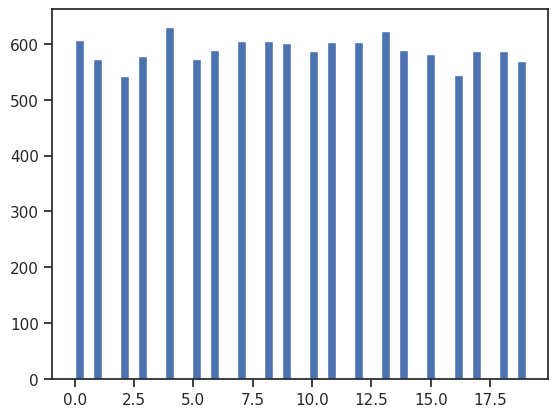

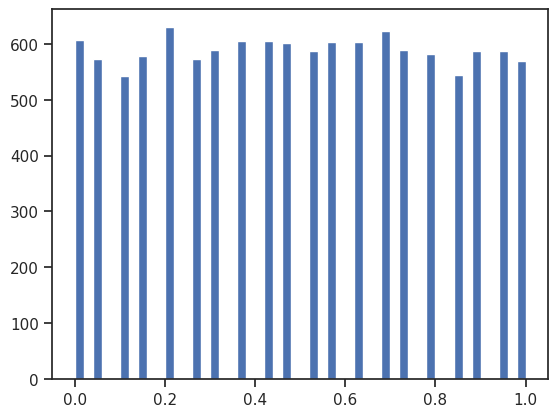

In [ ]:
sc1 = MinMaxScaler()
sc1_data = sc1.fit_transform(data[['monthly_store_visits']])
plt.hist(data['monthly_store_visits'], 50)
plt.show()